# Influenza Forecasting — DeepONet Surrogate Trajectories

**Method:** Train a DeepONet operator network to emulate the two-strain vaccination ODE.
Once trained, the network generates thousands of synthetic trajectories in milliseconds
(no ODE solver required per sample).

## Workflow
1. **Setup** — imports, file paths, and all configurable settings
2. **Data loading** — weekly influenza A/B hospitalization rates
3. **ODE model** — two-strain vaccination model (used to generate DeepONet training data)
4. **DeepONet surrogate** — train, validate, and generate synthetic trajectories
5. **CNN / LSTM evaluation** — forecasters trained and benchmarked on DeepONet-generated data


## 0. Imports & Settings

In [14]:
# ============================================================
# 0. IMPORTS AND PROJECT SETTINGS
# ============================================================

from __future__ import annotations

from dataclasses import dataclass, asdict, replace
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
import json
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy.integrate import solve_ivp
from scipy.optimize import differential_evolution, least_squares
from scipy.stats import qmc

# ============================================================
# FILE PATHS
# ============================================================
ROOT = Path("influenza_A_B_overall_three_compartments")
ROOT.mkdir(parents=True, exist_ok=True)

INPUT_LONG_CSV = ROOT / "weekly_rate_average_median_min_max_by_network_virus.csv"
if not INPUT_LONG_CSV.exists() and (Path("/mnt/data") / INPUT_LONG_CSV.name).exists():
    INPUT_LONG_CSV = Path("/mnt/data") / INPUT_LONG_CSV.name

SUMMARY_BY_STRAIN_CSV  = ROOT / "weekly_rate_overall_median_AplusB.csv"
SUMMARY_BY_STRAIN_PNG  = ROOT / "weekly_rate_overall_median_AplusB.png"

FIT_OUTPUT_CSV      = ROOT / "paper_two_strain_fit_weekly_rates.csv"
PARAM_OUTPUT_CSV    = ROOT / "paper_two_strain_fit_parameters.csv"
FIT_OUTPUT_PNG      = ROOT / "paper_two_strain_fit_weekly_rates.png"
FIT_ONLY_OUTPUT_PNG = ROOT / "paper_two_strain_fitted_trajectory_only.png"

VIRTUAL_OUTPUT_CSV          = ROOT / "virtual_paper_two_strain_dataset.csv"
VIRTUAL_BY_STRAIN_OUTPUT_CSV= ROOT / "virtual_paper_two_strain_patients_by_strain.csv"
VIRTUAL_STRAIN1_OUTPUT_CSV  = ROOT / "virtual_paper_two_strain_patients_influenza_A.csv"
VIRTUAL_STRAIN2_OUTPUT_CSV  = ROOT / "virtual_paper_two_strain_patients_influenza_B.csv"
VIRTUAL_OUTPUT_PNG          = ROOT / "virtual_paper_two_strain_examples.png"

# ============================================================
# DATA COLUMN SETTINGS
# ============================================================
WEEK_COL   = "week"
VALUE_COL  = "median_WEEKLY_RATE"
STRAIN_COL = "VIRUS"
STATUS_COL = None

GOOD_STATUS_VALUE = "good_0_29"

STRAIN1_MATCH = "Influenza A"
STRAIN2_MATCH = "Influenza B"
STRAIN1_NAME  = "Influenza A"
STRAIN2_NAME  = "Influenza B"

# ============================================================
# ODE MODEL SETTINGS
# ============================================================
MODEL_VERSION = "homogeneous"

DEGREES = np.arange(1, 11, dtype=float)
P_K = np.ones_like(DEGREES, dtype=float)
P_K = P_K / P_K.sum()

# ============================================================
# ODE SOLVER / FITTING SETTINGS
# (used only to build DeepONet training data — no global fit is run)
# ============================================================
USE_WEIGHTED_FIT = True
RANDOM_SEED      = 123
DE_WORKERS       = max(1, (os.cpu_count() or 2))
FIT_TO_TOTAL_ONLY = True

FIXED_VALUES = {
    "r":      0.02,
    "mu":     0.0,
    "nu1":    0.0,
    "nu2":    0.0,
    "Lambda": 0.0,
    "V0":     0.0,
}

USE_TIME_VARYING_BETA         = False
BETA_MULTIPLIER_SMOOTH_WINDOW = 1
BETA_MULTIPLIER_GROWTH_GAIN   = 3.0
BETA_MULTIPLIER_MIN           = 0.05
BETA_MULTIPLIER_MAX           = 8.00

FIT_PARAMETER_NAMES = [
    "beta1", "beta2", "sigma",
    "gamma1", "gamma2",
    "r", "mu", "nu1", "nu2", "Lambda",
    "I10", "I20", "V0",
    "rho1", "rho2",
]

PARAMETER_BOUNDS = {
    "beta1":  (1e-4, 10.0),
    "beta2":  (1e-4, 10.0),
    "sigma":  (1e-8, 10.0),
    "I10":    (1e-10, 0.20),
    "I20":    (1e-10, 0.20),
    "rho1":   (1e-8,  1e8),
    "rho2":   (1e-8,  1e8),
    "gamma1": (0.2,   4.0),
    "gamma2": (0.2,   4.0),
    "r":      (1e-8,  1.0),
    "mu":     (1e-8,  0.05),
    "nu1":    (1e-8,  1.0),
    "nu2":    (1e-8,  1.0),
    "Lambda": (1e-8,  0.10),
    "V0":     (1e-10, 0.50),
}

# ============================================================
# DEEPONET SURROGATE SETTINGS
# ============================================================
# Parameters that drive the ODE dynamics.  rho1/rho2 are excluded because
# they only rescale infected fractions into weekly rates and are sampled
# analytically after the operator prediction.
DEEPONET_DYNAMICS_PARAM_NAMES = [
    "beta1", "beta2", "sigma", "gamma1", "gamma2",
    "r", "mu", "nu1", "nu2", "Lambda", "I10", "I20", "V0",
]

# Training-data generation (ground-truth from ODE solves)
N_OPERATOR_TRAIN_SAMPLES = 50000
N_OPERATOR_VAL_SAMPLES   = 400
OPERATOR_DATA_SEED       = 1234

# Network architecture
DEEPONET_HIDDEN_DIM    = 128
DEEPONET_HIDDEN_LAYERS = 3
DEEPONET_LATENT_DIM    = 64

# Training hyperparameters
DEEPONET_LR           = 2e-3
DEEPONET_WEIGHT_DECAY = 1e-5
DEEPONET_EPOCHS       = 300
DEEPONET_BATCH_SIZE   = 64

# log1p compression scale for infected-fraction targets
DEEPONET_TARGET_SCALE = 50.0

DEEPONET_DEVICE = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

# Synthetic dataset generation from the trained operator
N_DEEPONET_SYNTHETIC_TRAJECTORIES = 10_000
DEEPONET_SYNTHETIC_SEED           = 99

# rho1/rho2 sampling range (log-uniform around an observed-data-calibrated center)
DEEPONET_RHO_SPREAD = 10.0

MIN_DEEPONET_TRAJECTORY_MEAN_RATE   = 0.20
MAX_DEEPONET_GENERATION_ATTEMPTS    = N_DEEPONET_SYNTHETIC_TRAJECTORIES * 500
N_DEEPONET_EXAMPLE_PLOTS            = 10

# Output paths
DEEPONET_MODEL_PATH               = ROOT / "deeponet_operator.pt"
DEEPONET_TRAINING_HISTORY_PNG     = ROOT / "deeponet_training_history.png"
DEEPONET_VALIDATION_PNG           = ROOT / "deeponet_validation_examples.png"
DEEPONET_VIRTUAL_OUTPUT_CSV       = ROOT / "deeponet_virtual_paper_two_strain_dataset.csv"
DEEPONET_VIRTUAL_BY_STRAIN_OUTPUT_CSV = ROOT / "deeponet_virtual_paper_two_strain_patients_by_strain.csv"
DEEPONET_VIRTUAL_STRAIN1_OUTPUT_CSV   = ROOT / "deeponet_virtual_paper_two_strain_patients_influenza_A.csv"
DEEPONET_VIRTUAL_STRAIN2_OUTPUT_CSV   = ROOT / "deeponet_virtual_paper_two_strain_patients_influenza_B.csv"
DEEPONET_VIRTUAL_EXAMPLES_PNG         = ROOT / "deeponet_virtual_examples.png"

print(f"DeepONet device: {DEEPONET_DEVICE}")


DeepONet device: mps


## 1. Load and summarize weekly rates by strain

In [15]:
# ============================================================
# 1. DATA LOADING AND WEEKLY SUMMARY
# ============================================================
# This version is for the pre-summarized file:
# weekly_rate_average_median_min_max_by_network_virus.csv
#
# It creates observed curves for each strain and for total A+B:
#     observed Influenza A median, observed Influenza B median, observed total median
#
# Steps:
#   1. Read median/min/max WEEKLY_RATE for each NETWORK, VIRUS, week.
#   2. Across networks, summarize each VIRUS and week.
#   3. Add Influenza A + Influenza B summaries to get total A+B.
#
# With FIT_TO_TOTAL_ONLY=False, this gives the model strain-specific weekly-rate targets.

def find_column(df: pd.DataFrame, candidates: list[str]) -> str | None:
    """Return the first matching column, ignoring case and spaces."""
    normalized = {str(c).lower().replace(" ", "").replace("_", ""): c for c in df.columns}
    for cand in candidates:
        key = cand.lower().replace(" ", "").replace("_", "")
        if key in normalized:
            return normalized[key]
    return None


def sigma_from_interval(lower: np.ndarray, upper: np.ndarray) -> np.ndarray:
    """Convert an interval to an approximate standard error for weighted fitting."""
    sigma = (upper - lower) / (2 * 1.96)
    sigma = np.asarray(sigma, dtype=float)

    valid = np.isfinite(sigma) & (sigma > 0)
    if valid.any():
        replacement = float(np.median(sigma[valid]))
    else:
        replacement = 1.0

    sigma[~np.isfinite(sigma)] = replacement
    sigma[sigma <= 0] = replacement
    return sigma


def build_overall_median_AplusB_summary(input_csv: Path) -> pd.DataFrame:
    """
    Build strain-specific median curves and observed min/max envelopes.

    The input file is expected to be:
        weekly_rate_average_median_min_max_by_network_virus.csv

    Required columns:
        NETWORK, VIRUS, week, median_WEEKLY_RATE, min_WEEKLY_RATE, max_WEEKLY_RATE
    """
    df = pd.read_csv(input_csv)

    required = [
        "NETWORK", "VIRUS", "week",
        "median_WEEKLY_RATE", "min_WEEKLY_RATE", "max_WEEKLY_RATE",
    ]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns {missing}. Available columns: {list(df.columns)}")

    df = df.copy()
    df["week"] = pd.to_numeric(df["week"], errors="coerce")
    for col in ["median_WEEKLY_RATE", "min_WEEKLY_RATE", "max_WEEKLY_RATE"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=required).copy()
    df["week"] = df["week"].astype(int)

    # Keep only Influenza A and Influenza B.
    df["VIRUS"] = df["VIRUS"].astype(str).str.strip()
    df = df[df["VIRUS"].isin([STRAIN1_NAME, STRAIN2_NAME])].copy()

    if df.empty:
        raise ValueError(
            f"No rows found for {STRAIN1_NAME!r} or {STRAIN2_NAME!r}. "
            f"Unique VIRUS values were: {pd.read_csv(input_csv)['VIRUS'].unique().tolist()}"
        )

    def summarize_strain(virus_name: str, prefix: str) -> pd.DataFrame:
        strain = df[df["VIRUS"] == virus_name].copy()
        if strain.empty:
            return pd.DataFrame(columns=[
                "week", f"median_{prefix}", f"min_observed_{prefix}",
                f"max_observed_{prefix}", f"n_networks_{prefix}",
            ])

        return (
            strain.groupby("week", as_index=False)
            .agg(**{
                f"median_{prefix}": ("median_WEEKLY_RATE", "median"),
                f"min_observed_{prefix}": ("min_WEEKLY_RATE", "min"),
                f"max_observed_{prefix}": ("max_WEEKLY_RATE", "max"),
                f"n_networks_{prefix}": ("NETWORK", "nunique"),
            })
            .sort_values("week")
            .reset_index(drop=True)
        )

    summary = summarize_strain(STRAIN1_NAME, "strain1").merge(
        summarize_strain(STRAIN2_NAME, "strain2"),
        on="week",
        how="outer",
    )
    summary = summary.sort_values("week").reset_index(drop=True)

    rate_cols = [
        "median_strain1", "median_strain2",
        "min_observed_strain1", "min_observed_strain2",
        "max_observed_strain1", "max_observed_strain2",
    ]
    for col in rate_cols:
        summary[col] = pd.to_numeric(summary[col], errors="coerce").fillna(0.0)

    for col in ["n_networks_strain1", "n_networks_strain2"]:
        summary[col] = pd.to_numeric(summary[col], errors="coerce").fillna(0).astype(int)

    summary["median_total"] = summary["median_strain1"] + summary["median_strain2"]
    summary["min_observed_total"] = summary["min_observed_strain1"] + summary["min_observed_strain2"]
    summary["max_observed_total"] = summary["max_observed_strain1"] + summary["max_observed_strain2"]
    summary["n_networks"] = summary[["n_networks_strain1", "n_networks_strain2"]].max(axis=1)

    # Keep the older lower/upper names for the fitting code, but they are min/max bounds.
    summary["lower_95_strain1"] = summary["min_observed_strain1"]
    summary["upper_95_strain1"] = summary["max_observed_strain1"]
    summary["lower_95_strain2"] = summary["min_observed_strain2"]
    summary["upper_95_strain2"] = summary["max_observed_strain2"]
    summary["lower_95_total"] = summary["min_observed_total"]
    summary["upper_95_total"] = summary["max_observed_total"]

    return summary[[
        "week",
        "median_strain1", "min_observed_strain1", "max_observed_strain1",
        "median_strain2", "min_observed_strain2", "max_observed_strain2",
        "median_total", "min_observed_total", "max_observed_total",
        "lower_95_strain1", "upper_95_strain1",
        "lower_95_strain2", "upper_95_strain2",
        "lower_95_total", "upper_95_total",
        "n_networks_strain1", "n_networks_strain2", "n_networks",
    ]]


summary = build_overall_median_AplusB_summary(INPUT_LONG_CSV)
summary.to_csv(SUMMARY_BY_STRAIN_CSV, index=False)

# print("Using uploaded precomputed data:")
# print(INPUT_LONG_CSV)

# print("\nSummary columns:")
# print(list(summary.columns))

# print("\nSaved:")
# print(SUMMARY_BY_STRAIN_CSV)

# summary.head()


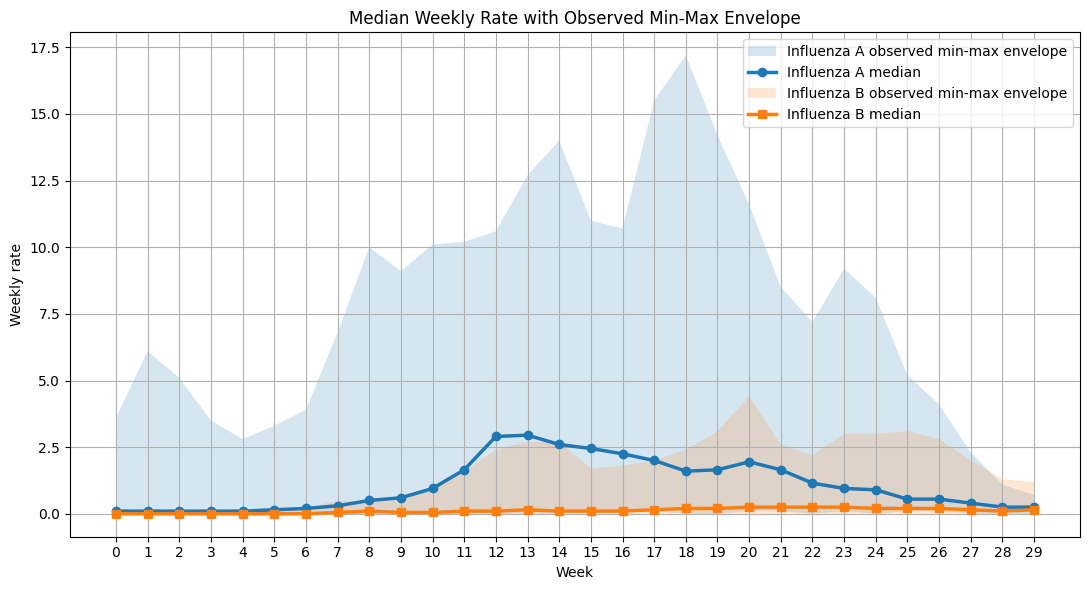

Saved graph:
influenza_A_B_overall_three_compartments/weekly_rate_overall_median_AplusB.png


In [16]:
# ============================================================
# 1C. PLOT WEEKLY SUMMARY (AGGREGATE + PER-CATEGORY FACETS)
# ============================================================

def plot_weekly_summary(summary: pd.DataFrame, output_png: Path) -> None:
    plt.figure(figsize=(11, 6))

    if {"median_strain1", "median_strain2"}.issubset(summary.columns):
        plt.fill_between(
            summary["week"],
            summary["min_observed_strain1"],
            summary["max_observed_strain1"],
            alpha=0.18,
            label=f"{STRAIN1_NAME} observed min-max envelope",
        )
        plt.plot(
            summary["week"],
            summary["median_strain1"],
            marker="o",
            linewidth=2.5,
            label=f"{STRAIN1_NAME} median",
        )

        plt.fill_between(
            summary["week"],
            summary["min_observed_strain2"],
            summary["max_observed_strain2"],
            alpha=0.18,
            label=f"{STRAIN2_NAME} observed min-max envelope",
        )
        plt.plot(
            summary["week"],
            summary["median_strain2"],
            marker="s",
            linewidth=2.5,
            label=f"{STRAIN2_NAME} median",
        )

    else:
        plt.fill_between(
            summary["week"],
            summary["min_observed_total"],
            summary["max_observed_total"],
            alpha=0.20,
            label="Observed min-max envelope",
        )
        plt.plot(
            summary["week"],
            summary["median_total"],
            marker="o",
            linewidth=2.5,
            label="Total median",
        )

    plt.xlabel("Week")
    plt.ylabel("Weekly rate")
    plt.title("Median Weekly Rate with Observed Min-Max Envelope")
    plt.xticks(range(int(summary["week"].min()), int(summary["week"].max()) + 1))
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_png, dpi=300)
    plt.show()

plot_weekly_summary(summary, SUMMARY_BY_STRAIN_PNG)

print("Saved graph:")
print(SUMMARY_BY_STRAIN_PNG)


## 2. Two-Strain Vaccination ODE Model

The same ODE used by the perturbation notebook. Here it serves as the *ground-truth* solver that generates DeepONet training data.

## Homogeneous Two-Strain Vaccination Model

$$
\frac{dS}{dt} = \Lambda - (\beta_1(t) I_1 + \beta_2(t) I_2 + \lambda)S
$$

$$
\frac{dV_1}{dt} = rS - (\mu + \sigma I_2)V_1
$$

$$
\frac{dI_1}{dt} = \beta_1(t) I_1 S - \alpha_1 I_1
$$

$$
\frac{dI_2}{dt} = \beta_2(t) I_2 S + \sigma I_2 V_1 - \alpha_2 I_2
$$

$$
\frac{dR}{dt} = \gamma_1 I_1 + \gamma_2 I_2 - \mu R
$$

where

$$
\lambda = r + \mu
$$

$$
\alpha_1 = \gamma_1 + \nu_1 + \mu
$$

$$
\alpha_2 = \gamma_2 + \nu_2 + \mu
$$

Here transmission is allowed to vary smoothly through time:

$$
\beta_i(t) = \beta_i \left[1 + a_i \exp\left(-\frac{1}{2}\left(\frac{t - \tau_i}{w_i}\right)^2\right)\right]
$$

where $a_i$ is the fitted seasonal boost, $\tau_i$ is the fitted peak week, and $w_i$ is the fitted width.

## Network Two-Strain Vaccination Model

For each degree group $k = 1,2,\dots,n$,

$$
\frac{dS_k}{dt} = \Lambda - \beta_1(t) k S_k \Theta_1 - \beta_2(t) k S_k \Theta_2 - \lambda S_k
$$

$$
\frac{dV_k}{dt} = rS_k - \mu V_k - \sigma k V_k \Theta_2
$$

$$
\frac{dI_k}{dt} = \beta_1(t) k S_k \Theta_1 - \alpha_1 I_k
$$

$$
\frac{dJ_k}{dt} = \beta_2(t) k S_k \Theta_2 + \sigma k V_k \Theta_2 - \alpha_2 J_k
$$

$$
\frac{dR_k}{dt} = \gamma_1 I_k + \gamma_2 J_k - \mu R_k
$$

where

$$
\lambda = r + \mu
$$

$$
\alpha_1 = \gamma_1 + \nu_1 + \mu
$$

$$
\alpha_2 = \gamma_2 + \nu_2 + \mu
$$

## Network Infection Pressure Terms

$$
\Theta_1(t) =
\frac{\sum_{h=1}^{n} hP(h)I_h(t)}
{\langle k \rangle}
$$

$$
\Theta_2(t) =
\frac{\sum_{h=1}^{n} hP(h)J_h(t)}
{\langle k \rangle}
$$

where

$$
\langle k \rangle = \sum_{h=1}^{n} hP(h)
$$

In [17]:
# ============================================================
# 2. ODE MODEL DEFINITIONS
# ============================================================

@dataclass
class PaperParams:
    beta1: float
    beta2: float
    sigma: float
    gamma1: float
    gamma2: float
    r: float
    mu: float
    nu1: float
    nu2: float
    Lambda: float
    rho1: float
    rho2: float
    I10: float
    I20: float
    V0: float = 0.0


def alpha1(p: PaperParams) -> float:
    return p.gamma1 + p.nu1 + p.mu


def alpha2(p: PaperParams) -> float:
    return p.gamma2 + p.nu2 + p.mu


def make_observed_beta_multiplier(values: np.ndarray) -> np.ndarray:
    """Build a fixed week-by-week beta multiplier from observed median rates."""
    values = np.asarray(values, dtype=float)
    values = np.maximum(values, 0.0)

    if BETA_MULTIPLIER_SMOOTH_WINDOW > 1:
        values = pd.Series(values).rolling(
            window=BETA_MULTIPLIER_SMOOTH_WINDOW,
            center=True,
            min_periods=1,
        ).mean().to_numpy(dtype=float)

    positive = values[values > 0]
    if len(positive) == 0:
        return np.ones_like(values, dtype=float)

    floor = max(float(np.min(positive)) * 0.50, 1e-6)
    safe_values = np.maximum(values, floor)
    growth = np.empty_like(safe_values, dtype=float)
    growth[:-1] = np.diff(np.log(safe_values))
    growth[-1] = growth[-2] if len(growth) > 1 else 0.0

    raw_multiplier = 1.0 + BETA_MULTIPLIER_GROWTH_GAIN * growth
    positive_raw = raw_multiplier[raw_multiplier > 0]
    if len(positive_raw) == 0:
        return np.ones_like(values, dtype=float)

    multiplier = raw_multiplier / float(np.mean(positive_raw))
    return np.clip(multiplier, BETA_MULTIPLIER_MIN, BETA_MULTIPLIER_MAX)


if USE_TIME_VARYING_BETA and "summary" in globals():
    BETA_TIME_GRID = summary["week"].to_numpy(dtype=float)
    BETA1_TIME_MULTIPLIER = make_observed_beta_multiplier(summary["median_strain1"].to_numpy(dtype=float))
    BETA2_TIME_MULTIPLIER = make_observed_beta_multiplier(summary["median_strain2"].to_numpy(dtype=float))
else:
    BETA_TIME_GRID = None
    BETA1_TIME_MULTIPLIER = None
    BETA2_TIME_MULTIPLIER = None


def beta_multiplier_at(t: float, multipliers: np.ndarray | None) -> float:
    if not USE_TIME_VARYING_BETA or BETA_TIME_GRID is None or multipliers is None:
        return 1.0
    idx = int(np.searchsorted(BETA_TIME_GRID, float(t), side="right") - 1)
    idx = int(np.clip(idx, 0, len(multipliers) - 1))
    return float(multipliers[idx])


def beta1_t(t: float, p: PaperParams) -> float:
    return p.beta1 * beta_multiplier_at(t, BETA1_TIME_MULTIPLIER)


def beta2_t(t: float, p: PaperParams) -> float:
    return p.beta2 * beta_multiplier_at(t, BETA2_TIME_MULTIPLIER)


def paper_homogeneous_rhs(t: float, y: np.ndarray, p: PaperParams) -> list[float]:
    """
    Paper's original aggregate two-strain vaccination model.

    y = [S, V, I1, I2, R]
    """
    S, V, I1, I2, R = y

    # Small numerical protection
    S = max(S, 0.0)
    V = max(V, 0.0)
    I1 = max(I1, 0.0)
    I2 = max(I2, 0.0)

    lam = p.r + p.mu
    b1 = beta1_t(t, p)
    b2 = beta2_t(t, p)

    new1 = b1 * I1 * S
    new2 = b2 * I2 * S + p.sigma * I2 * V

    dS = p.Lambda - (b1 * I1 + b2 * I2 + lam) * S
    dV = p.r * S - (p.mu + p.sigma * I2) * V
    dI1 = new1 - alpha1(p) * I1
    dI2 = new2 - alpha2(p) * I2
    dR = p.gamma1 * I1 + p.gamma2 * I2 - p.mu * R

    return [dS, dV, dI1, dI2, dR]


def paper_network_rhs(t: float, y: np.ndarray, p: PaperParams, degrees: np.ndarray, pk: np.ndarray) -> np.ndarray:
    """
    Paper's original complex-network model.

    For n degree classes, y stacks:
        S[0:n], V[0:n], I[0:n], J[0:n], R[0:n]
    """
    n = len(degrees)

    S = np.maximum(y[0:n], 0.0)
    V = np.maximum(y[n:2*n], 0.0)
    I = np.maximum(y[2*n:3*n], 0.0)
    J = np.maximum(y[3*n:4*n], 0.0)
    R = y[4*n:5*n]

    mean_k = np.sum(degrees * pk)
    theta1 = np.sum(degrees * pk * I) / mean_k
    theta2 = np.sum(degrees * pk * J) / mean_k

    lam = p.r + p.mu
    b1 = beta1_t(t, p)
    b2 = beta2_t(t, p)

    new1 = b1 * degrees * S * theta1
    new2 = b2 * degrees * S * theta2 + p.sigma * degrees * V * theta2

    dS = p.Lambda - b1 * degrees * S * theta1 - b2 * degrees * S * theta2 - lam * S
    dV = p.r * S - p.mu * V - p.sigma * degrees * V * theta2
    dI = new1 - alpha1(p) * I
    dJ = new2 - alpha2(p) * J
    dR = p.gamma1 * I + p.gamma2 * J - p.mu * R

    return np.concatenate([dS, dV, dI, dJ, dR])


def make_initial_state(p: PaperParams, model_version: str) -> np.ndarray:
    if p.I10 + p.I20 + p.V0 >= 0.95:
        raise ValueError("Initial fractions are too large: I10 + I20 + V0 must be < 0.95.")

    if model_version == "homogeneous":
        S0 = 1.0 - p.V0 - p.I10 - p.I20
        return np.array([S0, p.V0, p.I10, p.I20, 0.0], dtype=float)

    if model_version == "network":
        degrees = np.asarray(DEGREES, dtype=float)
        n = len(degrees)

        S0 = np.full(n, 1.0 - p.V0 - p.I10 - p.I20, dtype=float)
        V0 = np.full(n, p.V0, dtype=float)
        I0 = np.full(n, p.I10, dtype=float)
        J0 = np.full(n, p.I20, dtype=float)
        R0 = np.zeros(n, dtype=float)

        return np.concatenate([S0, V0, I0, J0, R0])

    raise ValueError("model_version must be 'homogeneous' or 'network'.")


def simulate_paper_model(
    weeks: np.ndarray,
    p: PaperParams,
    model_version: str = MODEL_VERSION,
) -> pd.DataFrame:
    """
    Simulate the original two-strain model and return weekly predicted rates.

    Rates are scaled from the infected-state trajectories. For network simulations,
    infected states are aggregated over degree classes by P(k).
    """
    weeks = np.asarray(weeks, dtype=int)
    max_week = int(np.max(weeks))

    t_eval = np.arange(0, max_week + 1, dtype=float)
    y0 = make_initial_state(p, model_version)

    if model_version == "homogeneous":
        rhs = lambda t, y: paper_homogeneous_rhs(t, y, p)
    elif model_version == "network":
        degrees = np.asarray(DEGREES, dtype=float)
        pk = np.asarray(P_K, dtype=float)
        pk = pk / pk.sum()
        rhs = lambda t, y: paper_network_rhs(t, y, p, degrees, pk)
    else:
        raise ValueError("MODEL_VERSION must be 'homogeneous' or 'network'.")

    sol = solve_ivp(
        fun=rhs,
        t_span=(0.0, float(max_week)),
        y0=y0,
        t_eval=t_eval,
        method="LSODA",
        rtol=1e-6,
        atol=1e-8,
    )

    if not sol.success:
        raise RuntimeError(f"ODE solver failed: {sol.message}")

    if model_version == "homogeneous":
        strain1_all = np.maximum(sol.y[2, :], 0.0)
        strain2_all = np.maximum(sol.y[3, :], 0.0)

    else:
        n = len(DEGREES)
        I = np.maximum(sol.y[2*n:3*n, :], 0.0)
        J = np.maximum(sol.y[3*n:4*n, :], 0.0)
        pk = np.asarray(P_K, dtype=float)
        pk = pk / pk.sum()

        strain1_all = np.sum(pk[:, None] * I, axis=0)
        strain2_all = np.sum(pk[:, None] * J, axis=0)

    pred1_all = p.rho1 * strain1_all
    pred2_all = p.rho2 * strain2_all

    out = pd.DataFrame({
        "week": weeks,
        "pred_strain1_rate": pred1_all[weeks],
        "pred_strain2_rate": pred2_all[weeks],
    })
    out["pred_total_rate"] = out["pred_strain1_rate"] + out["pred_strain2_rate"]
    return out


def reproduction_numbers(p: PaperParams) -> dict[str, float]:
    """
    Thresholds from the paper.

    For MODEL_VERSION = "homogeneous", <k^2>/<k> is set to 1.
    For MODEL_VERSION = "network", the network factor <k^2>/<k> is used.
    """
    lam = p.r + p.mu

    if lam <= 0:
        return {"R1": np.nan, "R2": np.nan}

    if MODEL_VERSION == "network":
        degrees = np.asarray(DEGREES, dtype=float)
        pk = np.asarray(P_K, dtype=float)
        pk = pk / pk.sum()
        network_factor = np.sum((degrees ** 2) * pk) / np.sum(degrees * pk)
    else:
        network_factor = 1.0

    R1 = (p.beta1 * p.Lambda / (alpha1(p) * lam)) * network_factor

    if p.mu > 0:
        R2 = (p.Lambda * (p.beta2 * p.mu + p.sigma * p.r) / (alpha2(p) * lam * p.mu)) * network_factor
    else:
        R2 = np.nan

    return {"R1": R1, "R2": R2}

## 2B. DeepONet operator surrogate: synthetic trajectories without fitting

This section replaces the optimization-based fit (section 3/3E) and the
perturb-and-resolve virtual dataset (section 4) with a learned **DeepONet**
operator surrogate for the section-2 ODE.

The idea:

1. Sample many parameter vectors from the same `PARAMETER_BOUNDS` used for
   fitting, and solve the section-2 ODE for each one to get ground-truth
   `I1(t)`, `I2(t)` trajectories. This is the operator's training data:
   *parameters -> trajectory*.
2. Train a DeepONet: a **branch network** encodes the parameter vector, a
   **trunk network** encodes the query time `t`, and their dot product gives
   the predicted trajectory.
3. Once trained, sample new parameter vectors (and independent `rho1`/`rho2`
   reporting-rate multipliers) and evaluate the DeepONet once - no ODE solve
   - to instantly produce a large, diverse synthetic dataset of weekly-rate
   trajectories.

This section only needs `summary`, `PaperParams`, `simulate_paper_model`,
`PARAMETER_BOUNDS`, and `MODEL_VERSION` from sections 0-2. It does not depend
on sections 3, 3E, 3F, or 4, and it overwrites `virtual_df` at the end so
section 5's CNN/LSTM forecasters can train on the DeepONet-generated dataset
unchanged.

### 2C. Generate ODE Training Trajectories (Latin Hypercube Sampling)

In [18]:
# ============================================================
# 2C. OPERATOR TRAINING DATA: SAMPLE PARAMETERS, SOLVE THE ODE
# ============================================================
# Builds (parameters -> trajectory) pairs by solving the section-2 ODE for
# parameter vectors drawn from PARAMETER_BOUNDS via Latin hypercube sampling
# (in log space, matching the fitting bounds). rho1 = rho2 = 1 here, so the
# targets are the raw infected fractions I1(t), I2(t), which are bounded in
# [0, 1] regardless of parameters.

DEEPONET_WEEKS = summary["week"].to_numpy(dtype=int)
DEEPONET_TRUNK = (DEEPONET_WEEKS / DEEPONET_WEEKS.max()).astype(np.float32).reshape(-1, 1)

_DEEPONET_LOG_LO = np.array([np.log(PARAMETER_BOUNDS[name][0]) for name in DEEPONET_DYNAMICS_PARAM_NAMES])
_DEEPONET_LOG_HI = np.array([np.log(PARAMETER_BOUNDS[name][1]) for name in DEEPONET_DYNAMICS_PARAM_NAMES])
_I10_IDX = DEEPONET_DYNAMICS_PARAM_NAMES.index("I10")
_I20_IDX = DEEPONET_DYNAMICS_PARAM_NAMES.index("I20")
_V0_IDX = DEEPONET_DYNAMICS_PARAM_NAMES.index("V0")


def sample_dynamics_params(n: int, seed: int) -> np.ndarray:
    """Latin-hypercube sample of dynamics parameters, in log space, rejecting
    combinations whose initial fractions exceed the I10 + I20 + V0 < 0.95 limit."""
    rng = np.random.default_rng(seed)
    accepted: list[np.ndarray] = []

    while len(accepted) < n:
        sampler = qmc.LatinHypercube(d=len(DEEPONET_DYNAMICS_PARAM_NAMES), seed=int(rng.integers(0, 2**31 - 1)))
        unit = sampler.random(n=max(n, 256))
        candidates = np.exp(_DEEPONET_LOG_LO + unit * (_DEEPONET_LOG_HI - _DEEPONET_LOG_LO))
        initial_fraction = candidates[:, _I10_IDX] + candidates[:, _I20_IDX] + candidates[:, _V0_IDX]
        accepted.extend(candidates[initial_fraction < 0.95].tolist())

    return np.array(accepted[:n], dtype=float)


def solve_operator_trajectory(dynamics_values: np.ndarray) -> np.ndarray:
    """Solve the section-2 ODE for one dynamics parameter vector and return
    [I1(t), I2(t)] (rho1 = rho2 = 1) on DEEPONET_WEEKS."""
    values = dict(zip(DEEPONET_DYNAMICS_PARAM_NAMES, dynamics_values))
    values["rho1"] = 1.0
    values["rho2"] = 1.0
    p = PaperParams(**values)
    pred = simulate_paper_model(DEEPONET_WEEKS, p, MODEL_VERSION)
    traj = np.stack([pred["pred_strain1_rate"].to_numpy(), pred["pred_strain2_rate"].to_numpy()], axis=-1)
    return np.clip(traj, 0.0, 1.0)


def build_operator_dataset(n: int, seed: int) -> tuple[np.ndarray, np.ndarray]:
    raw = sample_dynamics_params(n, seed)
    trajectories = np.stack([solve_operator_trajectory(row) for row in raw], axis=0)
    return raw, trajectories


print(f"Generating {N_OPERATOR_TRAIN_SAMPLES} training and {N_OPERATOR_VAL_SAMPLES} validation trajectories...")
operator_train_raw, operator_train_traj = build_operator_dataset(N_OPERATOR_TRAIN_SAMPLES, OPERATOR_DATA_SEED)
operator_val_raw, operator_val_traj = build_operator_dataset(N_OPERATOR_VAL_SAMPLES, OPERATOR_DATA_SEED + 1)

print(f"Training trajectories shape: {operator_train_traj.shape}")
print(
    f"I1/I2 range: [{operator_train_traj.min():.4f}, {operator_train_traj.max():.4f}], "
    f"mean={operator_train_traj.mean():.5f}"
)


Generating 50000 training and 400 validation trajectories...
Training trajectories shape: (50000, 30, 2)
I1/I2 range: [0.0000, 1.0000], mean=0.00943


### 2D. DeepONet Architecture (Branch Net + Trunk Net)

In [19]:
# ============================================================
# 2D. DEEPONET MODEL (PYTORCH)
# ============================================================
# Branch net encodes the 13 dynamics parameters; trunk net encodes the query
# time (week, normalized to [0, 1]). The two latent vectors are combined with
# a dot product per output channel (I1, I2), following Lu et al. 2021,
# "Learning nonlinear operators via DeepONet".

class DeepONet(nn.Module):
    def __init__(self, branch_dim: int, trunk_dim: int, hidden_dim: int, n_hidden_layers: int, latent_dim: int, n_outputs: int):
        super().__init__()
        self.latent_dim = latent_dim
        self.n_outputs = n_outputs

        def mlp(in_dim: int, out_dim: int) -> nn.Sequential:
            layers = [nn.Linear(in_dim, hidden_dim), nn.Tanh()]
            for _ in range(n_hidden_layers - 1):
                layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
            layers += [nn.Linear(hidden_dim, out_dim)]
            return nn.Sequential(*layers)

        self.branch_net = mlp(branch_dim, latent_dim * n_outputs)
        self.trunk_net = mlp(trunk_dim, latent_dim * n_outputs)
        self.bias = nn.Parameter(torch.zeros(n_outputs))

    def forward(self, branch_in: torch.Tensor, trunk_in: torch.Tensor) -> torch.Tensor:
        b = self.branch_net(branch_in).view(-1, self.n_outputs, self.latent_dim)
        t = torch.tanh(self.trunk_net(trunk_in)).view(-1, self.n_outputs, self.latent_dim)
        return torch.einsum("bok,tok->bto", b, t) + self.bias


def normalize_dynamics_params(raw: np.ndarray) -> np.ndarray:
    """Log-transform then rescale dynamics parameters to roughly [-1, 1] using PARAMETER_BOUNDS."""
    return 2.0 * (np.log(raw) - _DEEPONET_LOG_LO) / (_DEEPONET_LOG_HI - _DEEPONET_LOG_LO) - 1.0


def trajectory_to_target(traj: np.ndarray) -> np.ndarray:
    """Compress the [0, 1] infected fractions so small outbreaks are not swamped by large ones."""
    return np.log1p(traj * DEEPONET_TARGET_SCALE)


def target_to_trajectory(target: torch.Tensor) -> torch.Tensor:
    return torch.clamp(torch.expm1(target) / DEEPONET_TARGET_SCALE, min=0.0)


deeponet_model = DeepONet(
    branch_dim=len(DEEPONET_DYNAMICS_PARAM_NAMES),
    trunk_dim=1,
    hidden_dim=DEEPONET_HIDDEN_DIM,
    n_hidden_layers=DEEPONET_HIDDEN_LAYERS,
    latent_dim=DEEPONET_LATENT_DIM,
    n_outputs=2,
).to(DEEPONET_DEVICE)

print(deeponet_model)
print(f"Parameters: {sum(p.numel() for p in deeponet_model.parameters()):,}")


DeepONet(
  (branch_net): Sequential(
    (0): Linear(in_features=13, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=128, bias=True)
  )
  (trunk_net): Sequential(
    (0): Linear(in_features=1, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=128, bias=True)
  )
)
Parameters: 101,122


### 2E. Train the DeepONet Operator

epoch    0  train_mse=2.492329e-02  val_mse=2.592734e-02
epoch   25  train_mse=2.140375e-02  val_mse=2.299831e-02
epoch   50  train_mse=1.910788e-02  val_mse=2.100053e-02
epoch   75  train_mse=1.759184e-02  val_mse=2.265570e-02
epoch  100  train_mse=1.621514e-02  val_mse=2.079844e-02
epoch  125  train_mse=1.503013e-02  val_mse=1.732778e-02
epoch  150  train_mse=1.395696e-02  val_mse=1.514329e-02
epoch  175  train_mse=1.289058e-02  val_mse=1.549076e-02
epoch  200  train_mse=1.201840e-02  val_mse=1.335603e-02
epoch  225  train_mse=1.127588e-02  val_mse=1.264006e-02
epoch  250  train_mse=1.068559e-02  val_mse=1.218001e-02
epoch  275  train_mse=1.034800e-02  val_mse=1.175589e-02
epoch  299  train_mse=1.021877e-02  val_mse=1.176889e-02

Saved trained DeepONet to influenza_A_B_overall_three_compartments/deeponet_operator.pt


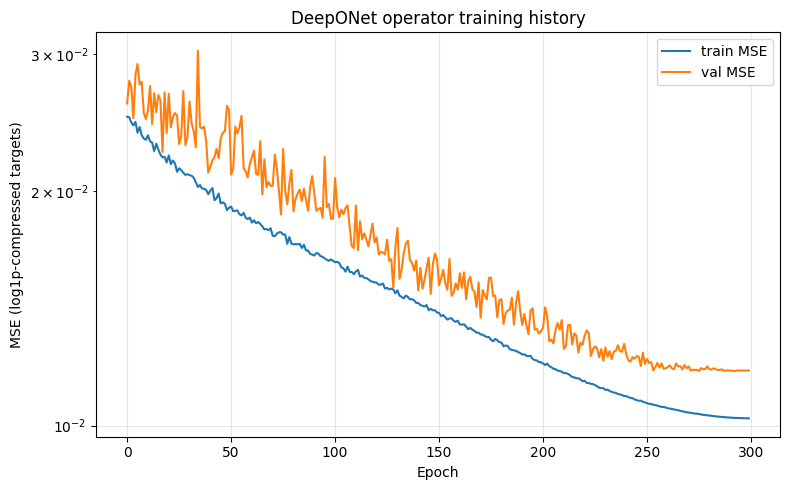

In [21]:
# ============================================================
# 2E. TRAIN THE DEEPONET OPERATOR
# ============================================================

branch_train = torch.tensor(normalize_dynamics_params(operator_train_raw), dtype=torch.float32, device=DEEPONET_DEVICE)
branch_val = torch.tensor(normalize_dynamics_params(operator_val_raw), dtype=torch.float32, device=DEEPONET_DEVICE)
trunk_in = torch.tensor(DEEPONET_TRUNK, dtype=torch.float32, device=DEEPONET_DEVICE)
target_train = torch.tensor(trajectory_to_target(operator_train_traj), dtype=torch.float32, device=DEEPONET_DEVICE)
target_val = torch.tensor(trajectory_to_target(operator_val_traj), dtype=torch.float32, device=DEEPONET_DEVICE)

optimizer = torch.optim.Adam(deeponet_model.parameters(), lr=DEEPONET_LR, weight_decay=DEEPONET_WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=DEEPONET_EPOCHS)

n_train = branch_train.shape[0]
train_history: list[float] = []
val_history: list[float] = []

for epoch in range(DEEPONET_EPOCHS):
    deeponet_model.train()
    perm = torch.randperm(n_train, device=DEEPONET_DEVICE)
    epoch_loss = 0.0

    for start in range(0, n_train, DEEPONET_BATCH_SIZE):
        idx = perm[start:start + DEEPONET_BATCH_SIZE]
        optimizer.zero_grad()
        pred = deeponet_model(branch_train[idx], trunk_in)
        loss = nn.functional.mse_loss(pred, target_train[idx])
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(idx)

    scheduler.step()
    train_history.append(epoch_loss / n_train)

    deeponet_model.eval()
    with torch.no_grad():
        val_loss = nn.functional.mse_loss(deeponet_model(branch_val, trunk_in), target_val).item()
    val_history.append(val_loss)

    if epoch % 25 == 0 or epoch == DEEPONET_EPOCHS - 1:
        print(f"epoch {epoch:4d}  train_mse={train_history[-1]:.6e}  val_mse={val_history[-1]:.6e}")

torch.save(deeponet_model.state_dict(), DEEPONET_MODEL_PATH)
print(f"\nSaved trained DeepONet to {DEEPONET_MODEL_PATH}")

plt.figure(figsize=(8, 5))
plt.plot(train_history, label="train MSE")
plt.plot(val_history, label="val MSE")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE (log1p-compressed targets)")
plt.title("DeepONet operator training history")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(DEEPONET_TRAINING_HISTORY_PNG, dpi=200)
plt.show()


### 2F. Validate: True ODE vs DeepONet Predictions

Validation absolute error: mean=0.00249, p95=0.00797, max=0.67433


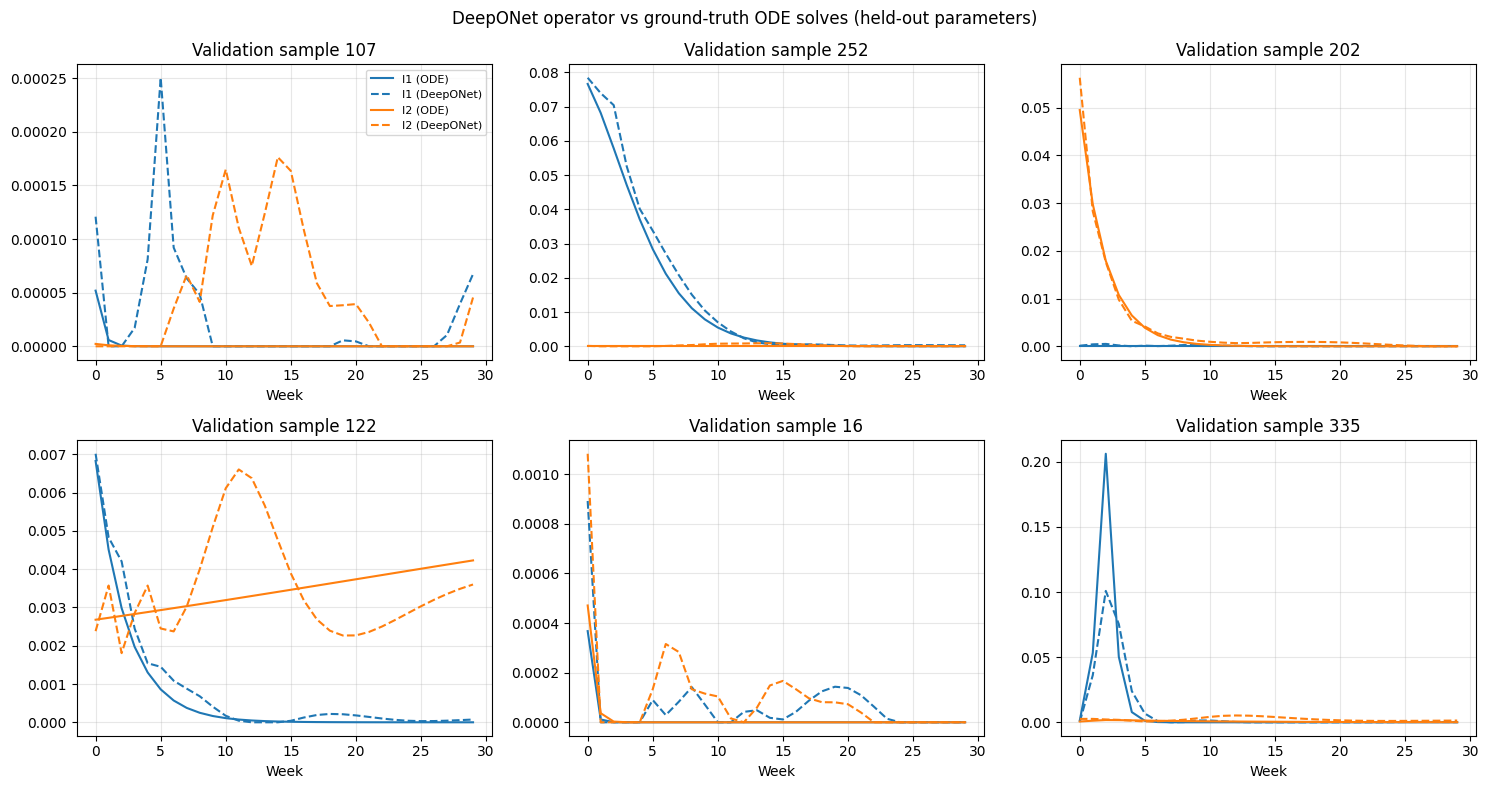

In [22]:
# ============================================================
# 2F. VALIDATE: TRUE ODE TRAJECTORIES VS DEEPONET PREDICTIONS
# ============================================================

deeponet_model.eval()
with torch.no_grad():
    val_pred = target_to_trajectory(deeponet_model(branch_val, trunk_in)).cpu().numpy()

abs_err = np.abs(val_pred - operator_val_traj)
print(f"Validation absolute error: mean={abs_err.mean():.5f}, p95={np.percentile(abs_err, 95):.5f}, max={abs_err.max():.5f}")

n_examples = 6
example_idx = np.random.default_rng(0).choice(len(operator_val_traj), size=n_examples, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, idx in zip(axes.flat, example_idx):
    ax.plot(DEEPONET_WEEKS, operator_val_traj[idx, :, 0], color="tab:blue", label="I1 (ODE)")
    ax.plot(DEEPONET_WEEKS, val_pred[idx, :, 0], color="tab:blue", linestyle="--", label="I1 (DeepONet)")
    ax.plot(DEEPONET_WEEKS, operator_val_traj[idx, :, 1], color="tab:orange", label="I2 (ODE)")
    ax.plot(DEEPONET_WEEKS, val_pred[idx, :, 1], color="tab:orange", linestyle="--", label="I2 (DeepONet)")
    ax.set_title(f"Validation sample {idx}")
    ax.set_xlabel("Week")
    ax.grid(True, alpha=0.3)

axes.flat[0].legend(fontsize=8)
fig.suptitle("DeepONet operator vs ground-truth ODE solves (held-out parameters)")
fig.tight_layout()
fig.savefig(DEEPONET_VALIDATION_PNG, dpi=200)
plt.show()


### 2G. Generate Synthetic Trajectories with the Trained Operator

Thousands of trajectories are produced by a single forward pass through the trained network — no ODE solves required.

In [23]:
# ============================================================
# 2G. GENERATE SYNTHETIC TRAJECTORIES WITH THE TRAINED OPERATOR
# ============================================================
# Sample new dynamics-parameter vectors from the same prior used for
# training, plus independent rho1/rho2 reporting-rate multipliers, then
# evaluate the DeepONet once per sample (no ODE solve) to get I1(t), I2(t).
# Weekly rates are rate = rho * I, exactly as in simulate_paper_model.
# Trajectories whose mean total rate falls below
# MIN_DEEPONET_TRAJECTORY_MEAN_RATE are rejected and resampled, matching the
# acceptance criterion used by section 4's perturbation-based generator.

def estimate_rho_bounds(observed_max_rate: float, operator_traj_strain: np.ndarray, spread: float) -> tuple[float, float]:
    """Center a log-uniform rho range so rho * typical_I_max matches the observed data scale."""
    per_traj_max = operator_traj_strain.max(axis=1)
    nontrivial = per_traj_max[per_traj_max > 1e-3]
    typical_I_max = float(np.percentile(nontrivial, 75)) if len(nontrivial) > 0 else float(per_traj_max.max())
    rho_center = observed_max_rate / typical_I_max
    return rho_center / spread, rho_center * spread


RHO1_BOUNDS = estimate_rho_bounds(float(summary["median_strain1"].max()), operator_train_traj[:, :, 0], DEEPONET_RHO_SPREAD)
RHO2_BOUNDS = estimate_rho_bounds(float(summary["median_strain2"].max()), operator_train_traj[:, :, 1], DEEPONET_RHO_SPREAD)
print(f"Estimated rho1 range: {RHO1_BOUNDS[0]:.4g} - {RHO1_BOUNDS[1]:.4g}")
print(f"Estimated rho2 range: {RHO2_BOUNDS[0]:.4g} - {RHO2_BOUNDS[1]:.4g}")


def sample_rho(n: int, seed: int) -> tuple[np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    rho1 = np.exp(rng.uniform(np.log(RHO1_BOUNDS[0]), np.log(RHO1_BOUNDS[1]), size=n))
    rho2 = np.exp(rng.uniform(np.log(RHO2_BOUNDS[0]), np.log(RHO2_BOUNDS[1]), size=n))
    return rho1, rho2


deeponet_model.eval()
rng = np.random.default_rng(DEEPONET_SYNTHETIC_SEED)

accepted_dynamics: list[np.ndarray] = []
accepted_rho: list[tuple[float, float]] = []
accepted_traj: list[np.ndarray] = []
attempts = 0
batch_size = 256

while len(accepted_traj) < N_DEEPONET_SYNTHETIC_TRAJECTORIES and attempts < MAX_DEEPONET_GENERATION_ATTEMPTS:
    n_batch = min(batch_size, MAX_DEEPONET_GENERATION_ATTEMPTS - attempts)
    raw = sample_dynamics_params(n_batch, int(rng.integers(0, 2**31 - 1)))
    rho1, rho2 = sample_rho(n_batch, int(rng.integers(0, 2**31 - 1)))

    branch = torch.tensor(normalize_dynamics_params(raw), dtype=torch.float32, device=DEEPONET_DEVICE)
    with torch.no_grad():
        pred = target_to_trajectory(deeponet_model(branch, trunk_in)).cpu().numpy()

    rates = pred * np.stack([rho1, rho2], axis=-1)[:, None, :]
    mean_total_rate = rates.sum(axis=-1).mean(axis=-1)

    for i in range(n_batch):
        attempts += 1
        if mean_total_rate[i] < MIN_DEEPONET_TRAJECTORY_MEAN_RATE:
            continue
        if len(accepted_traj) >= N_DEEPONET_SYNTHETIC_TRAJECTORIES:
            break
        accepted_dynamics.append(raw[i])
        accepted_rho.append((float(rho1[i]), float(rho2[i])))
        accepted_traj.append(rates[i])

if len(accepted_traj) < N_DEEPONET_SYNTHETIC_TRAJECTORIES:
    print(
        f"Warning: accepted only {len(accepted_traj)} of {N_DEEPONET_SYNTHETIC_TRAJECTORIES} "
        f"requested trajectories after {attempts} attempts. Try lowering "
        "MIN_DEEPONET_TRAJECTORY_MEAN_RATE or increasing MAX_DEEPONET_GENERATION_ATTEMPTS."
    )

deeponet_rows = []
for virtual_id, (dyn, (rho1, rho2), traj) in enumerate(zip(accepted_dynamics, accepted_rho, accepted_traj), start=1):
    values = dict(zip(DEEPONET_DYNAMICS_PARAM_NAMES, dyn))
    values["rho1"] = rho1
    values["rho2"] = rho2
    for week, (rate1, rate2) in zip(DEEPONET_WEEKS, traj):
        deeponet_rows.append({
            "virtual_id": virtual_id,
            "week": int(week),
            "virtual_strain1_rate": float(rate1),
            "virtual_strain2_rate": float(rate2),
            "virtual_total_rate": float(rate1 + rate2),
            **values,
        })

deeponet_virtual_df = pd.DataFrame(deeponet_rows)
deeponet_virtual_df.to_csv(DEEPONET_VIRTUAL_OUTPUT_CSV, index=False)


def make_deeponet_patients_by_strain(virtual_df: pd.DataFrame) -> pd.DataFrame:
    """Reshape joint two-strain trajectories into one row per (strain, virtual_id, week)."""
    parameter_cols = DEEPONET_DYNAMICS_PARAM_NAMES + ["rho1", "rho2"]
    strain_specs = [
        (STRAIN1_NAME, "A", "virtual_strain1_rate"),
        (STRAIN2_NAME, "B", "virtual_strain2_rate"),
    ]

    frames = []
    for strain_name, strain_id, rate_col in strain_specs:
        cols = ["virtual_id", "week", rate_col] + parameter_cols
        temp = virtual_df[cols].rename(columns={rate_col: "virtual_WEEKLY_RATE"}).copy()
        temp["strain"] = strain_name
        temp["strain_id"] = strain_id
        temp["virtual_patient_id"] = strain_id + "_" + temp["virtual_id"].astype(str).str.zfill(5)
        frames.append(temp)

    patients = pd.concat(frames, ignore_index=True)
    return patients.sort_values(["strain", "virtual_id", "week"]).reset_index(drop=True)


deeponet_patients_by_strain_df = make_deeponet_patients_by_strain(deeponet_virtual_df)
deeponet_patients_by_strain_df.to_csv(DEEPONET_VIRTUAL_BY_STRAIN_OUTPUT_CSV, index=False)
deeponet_patients_by_strain_df[deeponet_patients_by_strain_df["strain"] == STRAIN1_NAME].to_csv(DEEPONET_VIRTUAL_STRAIN1_OUTPUT_CSV, index=False)
deeponet_patients_by_strain_df[deeponet_patients_by_strain_df["strain"] == STRAIN2_NAME].to_csv(DEEPONET_VIRTUAL_STRAIN2_OUTPUT_CSV, index=False)

# Make this the default input for section 5's CNN/LSTM forecasters.
virtual_df = deeponet_virtual_df

print(f"Generated {len(accepted_traj)} synthetic trajectories in {attempts} attempts.")
print("Saved:")
print(DEEPONET_VIRTUAL_OUTPUT_CSV)
print(DEEPONET_VIRTUAL_BY_STRAIN_OUTPUT_CSV)
print(DEEPONET_VIRTUAL_STRAIN1_OUTPUT_CSV)
print(DEEPONET_VIRTUAL_STRAIN2_OUTPUT_CSV)

print("\nMean total weekly rate per trajectory:")
print(deeponet_virtual_df.groupby("virtual_id")["virtual_total_rate"].mean().describe())

deeponet_virtual_df.head()


Estimated rho1 range: 1.13 - 113
Estimated rho2 range: 0.08539 - 8.539
Generated 10000 synthetic trajectories in 73255 attempts.
Saved:
influenza_A_B_overall_three_compartments/deeponet_virtual_paper_two_strain_dataset.csv
influenza_A_B_overall_three_compartments/deeponet_virtual_paper_two_strain_patients_by_strain.csv
influenza_A_B_overall_three_compartments/deeponet_virtual_paper_two_strain_patients_influenza_A.csv
influenza_A_B_overall_three_compartments/deeponet_virtual_paper_two_strain_patients_influenza_B.csv

Mean total weekly rate per trajectory:
count    10000.000000
mean         1.562232
std          2.548206
min          0.200003
25%          0.327775
50%          0.614795
75%          1.534669
max         35.139043
Name: virtual_total_rate, dtype: float64


,virtual_id,week,virtual_strain1_rate,virtual_strain2_rate,virtual_total_rate,beta1,beta2,sigma,gamma1,gamma2,r,mu,nu1,nu2,Lambda,I10,I20,V0,rho1,rho2
0,1,0,0.152496,0.000000,0.152496,1.724928,0.002082,0.950742,0.506167,3.207945,0.001029,9.175625e-08,0.040012,0.000001,2.438849e-07,0.018653,1.888587e-09,0.007369,8.767652,1.084653
1,1,1,0.434209,0.000088,0.434297,1.724928,0.002082,0.950742,0.506167,3.207945,0.001029,9.175625e-08,0.040012,0.000001,2.438849e-07,0.018653,1.888587e-09,0.007369,8.767652,1.084653
2,1,2,1.512921,0.000000,1.512921,1.724928,0.002082,0.950742,0.506167,3.207945,0.001029,9.175625e-08,0.040012,0.000001,2.438849e-07,0.018653,1.888587e-09,0.007369,8.767652,1.084653
3,1,3,2.501433,0.000533,2.501966,1.724928,0.002082,0.950742,0.506167,3.207945,0.001029,9.175625e-08,0.040012,0.000001,2.438849e-07,0.018653,1.888587e-09,0.007369,8.767652,1.084653
4,1,4,2.469003,0.000000,2.469003,1.724928,0.002082,0.950742,0.506167,3.207945,0.001029,9.175625e-08,0.040012,0.000001,2.438849e-07,0.018653,1.888587e-09,0.007369,8.767652,1.084653


### 2H. Plot Example Synthetic Trajectories

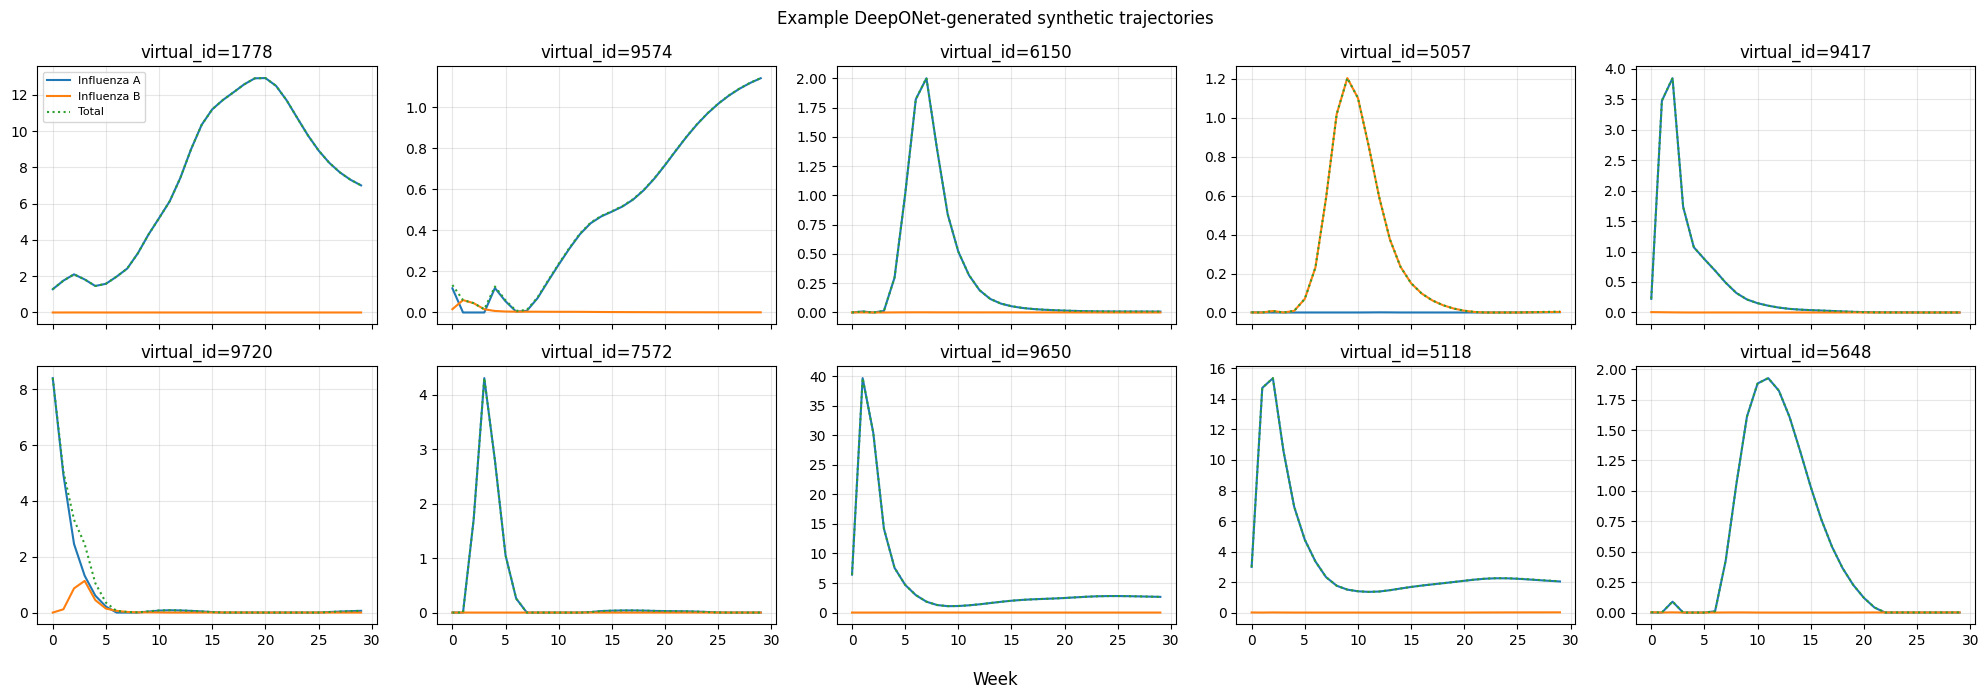

In [24]:
# ============================================================
# 2H. PLOT EXAMPLE SYNTHETIC TRAJECTORIES
# ============================================================

example_ids = np.random.default_rng(DEEPONET_SYNTHETIC_SEED).choice(
    deeponet_virtual_df["virtual_id"].unique(),
    size=min(N_DEEPONET_EXAMPLE_PLOTS, deeponet_virtual_df["virtual_id"].nunique()),
    replace=False,
)

fig, axes = plt.subplots(2, 5, figsize=(20, 7), sharex=True)
for ax, vid in zip(axes.flat, example_ids):
    traj = deeponet_virtual_df[deeponet_virtual_df["virtual_id"] == vid]
    ax.plot(traj["week"], traj["virtual_strain1_rate"], label=STRAIN1_NAME)
    ax.plot(traj["week"], traj["virtual_strain2_rate"], label=STRAIN2_NAME)
    ax.plot(traj["week"], traj["virtual_total_rate"], linestyle=":", label="Total")
    ax.set_title(f"virtual_id={vid}")
    ax.grid(True, alpha=0.3)

axes.flat[0].legend(fontsize=8)
fig.suptitle("Example DeepONet-generated synthetic trajectories")
fig.supxlabel("Week")
fig.tight_layout()
fig.savefig(DEEPONET_VIRTUAL_EXAMPLES_PNG, dpi=200)
plt.show()


## 5. CNN and LSTM Forecasters Trained on DeepONet Trajectories

Both models receive the first `GIVEN_VALUES` weeks of each synthetic trajectory as input and predict the remaining weeks. The `virtual_df` variable was set at the end of Section 2G and is used here directly.

In [ ]:
# ============================================================
# 5. OPTIONAL CNN AND LSTM FORECAST MODELS
# ============================================================
# Run this cell only after creating the virtual dataset.
# The default target is total weekly rate. You can change TARGET_COL
# to "virtual_strain1_rate" or "virtual_strain2_rate".

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, Dense, Dropout, Flatten, BatchNormalization, LSTM
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

TARGET_COL = "virtual_total_rate"
GIVEN_VALUES = 15
EPOCHS = 500
BATCH_SIZE = 16
LEARNING_RATE = 1e-3
USE_EARLY_STOPPING = True



CNN_MODEL_PATH = ROOT / f"cnn_paper_ode_{TARGET_COL}_given_{GIVEN_VALUES}.keras"
CNN_METADATA_PATH = ROOT / f"cnn_paper_ode_{TARGET_COL}_given_{GIVEN_VALUES}_metadata.json"
CNN_PREDICTIONS_CSV = ROOT / f"cnn_paper_ode_predictions_{TARGET_COL}_given_{GIVEN_VALUES}.csv"
CNN_PLOT_PATH = ROOT / f"cnn_paper_ode_forecast_{TARGET_COL}_given_{GIVEN_VALUES}.png"

LSTM_MODEL_PATH = ROOT / f"lstm_paper_ode_{TARGET_COL}_given_{GIVEN_VALUES}.keras"
LSTM_METADATA_PATH = ROOT / f"lstm_paper_ode_{TARGET_COL}_given_{GIVEN_VALUES}_metadata.json"
MODEL_COMPARISON_CSV = ROOT / f"model_comparison_{TARGET_COL}_given_{GIVEN_VALUES}.csv"
MODEL_COMPARISON_PNG = ROOT / f"model_comparison_{TARGET_COL}_given_{GIVEN_VALUES}.png"
MODEL_FORECAST_CSV = ROOT / f"cnn_lstm_forecast_{TARGET_COL}_given_{GIVEN_VALUES}.csv"
MODEL_FORECAST_PNG = ROOT / f"cnn_lstm_forecast_{TARGET_COL}_given_{GIVEN_VALUES}.png"


def make_supervised_dataset_from_virtual(
    virtual_df: pd.DataFrame,
    target_col: str,
    given_values: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    wide = (
        virtual_df.pivot(index="virtual_id", columns="week", values=target_col)
        .sort_index(axis=1)
        .dropna()
    )

    values = wide.to_numpy(dtype=float)
    weeks_arr = wide.columns.to_numpy(dtype=int)

    if given_values >= values.shape[1]:
        raise ValueError("GIVEN_VALUES must be smaller than the total number of weeks.")

    X = values[:, :given_values]
    y = values[:, given_values:]

    return X, y, weeks_arr


X_raw, y_raw, cnn_weeks = make_supervised_dataset_from_virtual(
    virtual_df=virtual_df,
    target_col=TARGET_COL,
    given_values=GIVEN_VALUES,
)

# Per-trajectory normalization: each sample is scaled using only the mean/std
# of its own "given" window, instead of one global mean/std over the whole
# dataset. With a global scale, trajectories whose amplitude is above average
# get compressed toward zero in normalized space, and an MSE loss then learns
# to systematically underpredict their peaks. Per-sample scaling lets the
# network focus on the *shape* of each trajectory regardless of its absolute
# size.
X_scale_mean = X_raw.mean(axis=1, keepdims=True)
X_scale_std = X_raw.std(axis=1, keepdims=True)

# Floor each trajectory's scale at the dataset-wide std of the "given"
# window. With 73 perturbation baselines spanning very different peak
# timings, many trajectories have a near-flat (near-zero-variance) given
# window even though weeks GIVEN_VALUES: still contain a real peak.
# Dividing by that near-zero std blew normalized targets up to the
# hundreds, which is why loss/val_loss were stuck around 1e5 and diverging.
GLOBAL_SCALE_FLOOR = float(X_raw.std())
X_scale_std = np.maximum(X_scale_std, GLOBAL_SCALE_FLOOR)

X = (X_raw - X_scale_mean) / X_scale_std
y = (y_raw - X_scale_mean) / X_scale_std

X = X[..., None]

n_samples = X.shape[0]
rng = np.random.default_rng(123)
idx = rng.permutation(n_samples)

split = int(0.80 * n_samples)
train_idx = idx[:split]
val_idx = idx[split:]

X_train, X_val = X[train_idx], X[val_idx]
y_train, y_val = y[train_idx], y[val_idx]
X_scale_mean_val = X_scale_mean[val_idx]
X_scale_std_val = X_scale_std[val_idx]

forecast_horizon = y.shape[1]

def make_training_callbacks() -> list:
    callbacks = []
    if USE_EARLY_STOPPING:
        callbacks.append(
            EarlyStopping(
                monitor="val_loss",
                patience=30,
                restore_best_weights=True,
            )
        )
    return callbacks


def build_cnn_model() -> Sequential:
    model = Sequential([
        Input(shape=(GIVEN_VALUES, 1)),
        Conv1D(32, kernel_size=3, activation="relu", padding="causal"),
        BatchNormalization(),
        Dropout(0.15),

        Conv1D(64, kernel_size=3, activation="relu", padding="causal"),
        BatchNormalization(),
        Dropout(0.15),

        Flatten(),
        Dense(64, activation="relu"),
        Dropout(0.10),
        Dense(forecast_horizon),
    ])
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="mse",
        metrics=["mae"],
    )
    return model


def build_lstm_model() -> Sequential:
    model = Sequential([
        Input(shape=(GIVEN_VALUES, 1)),
        LSTM(64, return_sequences=True),
        Dropout(0.15),
        LSTM(32),
        Dense(64, activation="relu"),
        Dropout(0.10),
        Dense(forecast_horizon),
    ])
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="mse",
        metrics=["mae"],
    )
    return model


def train_forecaster(
    model_name: str,
    build_model_fn,
    model_path: Path,
    metadata_path: Path,
) -> tuple[Sequential, object, dict]:
    tf.keras.utils.set_random_seed(123)
    model = build_model_fn()

    print(f"\nTraining {model_name} forecaster...")
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=make_training_callbacks(),
        verbose=1,
    )

    val_pred_scaled = model.predict(X_val, verbose=0)
    val_pred = val_pred_scaled * X_scale_std_val + X_scale_mean_val
    val_true = y_val * X_scale_std_val + X_scale_mean_val
    val_errors = val_pred - val_true
    best_val_loss = float(np.min(history.history["val_loss"]))
    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)

    metrics = {
        "model": model_name,
        "target_col": TARGET_COL,
        "given_values": int(GIVEN_VALUES),
        "forecast_horizon": int(forecast_horizon),
        "epochs_run": int(len(history.history["loss"])),
        "best_epoch": best_epoch,
        "best_val_loss_scaled": best_val_loss,
        "final_val_loss_scaled": float(history.history["val_loss"][-1]),
        "val_rmse": float(np.sqrt(np.mean(val_errors ** 2))),
        "val_mae": float(np.mean(np.abs(val_errors))),
        "model_path": str(model_path),
        "metadata_path": str(metadata_path),
    }

    model.save(model_path)
    metadata = {
        "MODEL_NAME": model_name,
        "TARGET_COL": TARGET_COL,
        "GIVEN_VALUES": GIVEN_VALUES,
        "TOTAL_WEEKS": int(len(cnn_weeks)),
        "FORECAST_HORIZON": int(forecast_horizon),
        "weeks": cnn_weeks.tolist(),
        "normalization": "per_sample_zscore_of_given_window",
        "scale_floor": GLOBAL_SCALE_FLOOR,
        "validation_metrics": metrics,
    }

    with open(metadata_path, "w") as f:
        json.dump(metadata, f, indent=2)

    return model, history, metrics


cnn_model, cnn_history, cnn_metrics = train_forecaster(
    "CNN",
    build_cnn_model,
    CNN_MODEL_PATH,
    CNN_METADATA_PATH,
)

lstm_model, lstm_history, lstm_metrics = train_forecaster(
    "LSTM",
    build_lstm_model,
    LSTM_MODEL_PATH,
    LSTM_METADATA_PATH,
)

model_comparison_df = pd.DataFrame([cnn_metrics, lstm_metrics]).sort_values("val_rmse")
model_comparison_df.to_csv(MODEL_COMPARISON_CSV, index=False)

plt.figure(figsize=(8, 5))
plt.bar(model_comparison_df["model"], model_comparison_df["val_rmse"])
plt.ylabel("Validation RMSE")
plt.title(f"CNN vs LSTM on {TARGET_COL}")
plt.grid(axis="y", alpha=0.35)
plt.tight_layout()
plt.savefig(MODEL_COMPARISON_PNG, dpi=300)
plt.show()

def observed_series_for_target(target_col: str) -> tuple[np.ndarray, np.ndarray, str]:
    if target_col == "virtual_total_rate":
        observed_col = "observed_total_rate"
        label = "Observed total"
        if observed_col in fit_df.columns:
            return fit_df["week"].to_numpy(dtype=int), fit_df[observed_col].to_numpy(dtype=float), label
        return summary["week"].to_numpy(dtype=int), summary["median_total"].to_numpy(dtype=float), label

    if target_col == "virtual_strain1_rate":
        observed_col = f"observed_{STRAIN1_NAME}_rate"
        label = f"Observed {STRAIN1_NAME}"
        if observed_col in fit_df.columns:
            return fit_df["week"].to_numpy(dtype=int), fit_df[observed_col].to_numpy(dtype=float), label
        return summary["week"].to_numpy(dtype=int), summary["median_strain1"].to_numpy(dtype=float), label

    if target_col == "virtual_strain2_rate":
        observed_col = f"observed_{STRAIN2_NAME}_rate"
        label = f"Observed {STRAIN2_NAME}"
        if observed_col in fit_df.columns:
            return fit_df["week"].to_numpy(dtype=int), fit_df[observed_col].to_numpy(dtype=float), label
        return summary["week"].to_numpy(dtype=int), summary["median_strain2"].to_numpy(dtype=float), label

    raise ValueError(f"No observed-series mapping for TARGET_COL={target_col!r}")


def forecast_observed_curve(model, observed_values: np.ndarray) -> np.ndarray:
    if len(observed_values) < len(cnn_weeks):
        raise ValueError(
            f"Observed curve has {len(observed_values)} values, but the model expects {len(cnn_weeks)} weeks."
        )

    observed_values = observed_values[:len(cnn_weeks)]
    given = observed_values[:GIVEN_VALUES]

    given_mean = float(given.mean())
    given_std = max(float(given.std()), GLOBAL_SCALE_FLOOR)

    X_user = ((given - given_mean) / given_std).reshape(1, GIVEN_VALUES, 1)
    pred_scaled = model.predict(X_user, verbose=0)[0]
    pred_future = pred_scaled * given_std + given_mean
    return np.concatenate([given, pred_future[: len(cnn_weeks) - GIVEN_VALUES]])


observed_weeks, observed_values, observed_label = observed_series_for_target(TARGET_COL)
observed_weeks = observed_weeks[:len(cnn_weeks)]
observed_values = observed_values[:len(cnn_weeks)]
cnn_forecast = forecast_observed_curve(cnn_model, observed_values)
lstm_forecast = forecast_observed_curve(lstm_model, observed_values)

forecast_df = pd.DataFrame({
    "week": observed_weeks,
    "observed_value": observed_values,
    "cnn_forecast": cnn_forecast,
    "lstm_forecast": lstm_forecast,
    "is_given_to_model": [True] * GIVEN_VALUES + [False] * (len(cnn_weeks) - GIVEN_VALUES),
})

for model_name in ["cnn", "lstm"]:
    forecast_df[f"{model_name}_error"] = forecast_df[f"{model_name}_forecast"] - forecast_df["observed_value"]
    forecast_df[f"{model_name}_absolute_error"] = np.abs(forecast_df[f"{model_name}_error"])
    forecast_df[f"{model_name}_squared_error"] = forecast_df[f"{model_name}_error"] ** 2

forecast_only = ~forecast_df["is_given_to_model"]
cnn_forecast_rmse = float(np.sqrt(forecast_df.loc[forecast_only, "cnn_squared_error"].mean()))
lstm_forecast_rmse = float(np.sqrt(forecast_df.loc[forecast_only, "lstm_squared_error"].mean()))
forecast_df["cnn_forecast_rmse"] = cnn_forecast_rmse
forecast_df["lstm_forecast_rmse"] = lstm_forecast_rmse
forecast_df.to_csv(MODEL_FORECAST_CSV, index=False)

plt.figure(figsize=(12, 7))
plt.plot(
    forecast_df["week"],
    forecast_df["observed_value"],
    marker="o",
    linewidth=2.5,
    label=observed_label,
)
plt.plot(
    forecast_df["week"],
    forecast_df["cnn_forecast"],
    marker="s",
    linestyle="--",
    linewidth=2.5,
    label=f"CNN forecast; RMSE={cnn_forecast_rmse:.4f}",
)
plt.plot(
    forecast_df["week"],
    forecast_df["lstm_forecast"],
    marker="^",
    linestyle="--",
    linewidth=2.5,
    label=f"LSTM forecast; RMSE={lstm_forecast_rmse:.4f}",
)
plt.axvline(
    x=int(forecast_df.loc[GIVEN_VALUES - 1, "week"]),
    linestyle=":",
    linewidth=2,
    label="Last given week",
)
plt.xlabel("Week")
plt.ylabel("Weekly rate")
plt.title(f"CNN vs LSTM Forecast on {TARGET_COL}")
plt.xticks(range(int(forecast_df["week"].min()), int(forecast_df["week"].max()) + 1))
plt.legend()
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig(MODEL_FORECAST_PNG, dpi=300)
plt.show()

model = cnn_model
history = cnn_history
metadata = {
    "TARGET_COL": TARGET_COL,
    "GIVEN_VALUES": GIVEN_VALUES,
    "TOTAL_WEEKS": int(len(cnn_weeks)),
    "FORECAST_HORIZON": int(forecast_horizon),
    "weeks": cnn_weeks.tolist(),
    "normalization": "per_sample_zscore_of_given_window",
    "scale_floor": GLOBAL_SCALE_FLOOR,
}

print("Saved CNN model:")
print(CNN_MODEL_PATH)

print("\nSaved LSTM model:")
print(LSTM_MODEL_PATH)

print("\nSaved model comparison:")
print(MODEL_COMPARISON_CSV)
print(MODEL_COMPARISON_PNG)

display(model_comparison_df)


2026-06-16 12:37:34.054152: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-06-16 12:37:34.054358: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-06-16 12:37:34.054362: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
I0000 00:00:1781631454.054704 17011815 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1781631454.055052 17011815 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



Training CNN forecaster...
Epoch 1/500


2026-06-16 12:37:34.806796: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 0.3343 - mae: 0.3267 - val_loss: 0.0531 - val_mae: 0.1018
Epoch 2/500
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 0.0758 - mae: 0.1322 - val_loss: 0.0334 - val_mae: 0.0762
Epoch 3/500
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.0633 - mae: 0.1194 - val_loss: 0.0296 - val_mae: 0.0757
Epoch 4/500
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0625 - mae: 0.1125 - val_loss: 0.0282 - val_mae: 0.0699
Epoch 5/500
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 0.0562 - mae: 0.1116 - val_loss: 0.0264 - val_mae: 0.0686
Epoch 6/500
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.0530 - mae: 0.1068 - val_loss: 0.0265 - val_mae: 0.0724
Epoch 7/500
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.0514 - mae: 0.1052 - val_loss: 0.0246 - val_mae: 0.0691
Epoch 8/500
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.0509 - mae: 0.1068 - val_loss: 0.0276 - val_mae: 0.0770
Epoch 9/500
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/

### 5C. Test Forecast Horizon on External CSV

In [ ]:
# ============================================================
# 5C. TEST CNN AND LSTM FORECAST HORIZON FROM CSV OR FOLDER
# ============================================================

from tensorflow.keras.models import load_model

# Use a single CSV, or set this to a folder containing CSV files.
# Examples:
#     TEST_INPUT_PATH = Path("influenzaA2018.csv")
#     TEST_INPUT_PATH = Path("influenza_A_B_overall_three_compartments/good_0_29")
# TEST_INPUT_PATH = Path("influenzaA2018.csv")
TEST_INPUT_PATH = Path("SIR_Synthetic_Data.csv")
# TEST_INPUT_PATH = Path("SIR_Synthetic_Data.csv")

# Leave as None to auto-detect the first numeric non-week column.
# For influenzaA2018.csv, auto-detection will choose "influenzaA2018".
TEST_VALUE_COL = None

FORECAST_HORIZON_TEST_OUTPUT_CSV = ROOT / "cnn_lstm_forecast_horizon_csv_test_results.csv"
FORECAST_HORIZON_TEST_OUTPUT_PNG = ROOT / "cnn_lstm_forecast_horizon_csv_test_prediction.png"


def clean_csv_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [str(col).replace("\ufeff", "").strip() for col in df.columns]
    return df


def find_week_column(df: pd.DataFrame) -> str | None:
    for col in df.columns:
        if str(col).lower().replace(" ", "").replace("_", "") == "week":
            return col
    return None


def normalize_column_name(name: str) -> str:
    return str(name).lower().replace(" ", "").replace("_", "").replace("-", "")


def find_value_column(
    df: pd.DataFrame,
    requested_col: str | None,
    min_values: int,
    csv_path: Path,
) -> str:
    if requested_col is not None:
        if requested_col not in df.columns:
            raise ValueError(f"Column {requested_col!r} not found. Available columns: {list(df.columns)}")
        return requested_col

    week_col = find_week_column(df)
    preferred_names = [
        csv_path.stem,
        "WEEKLY RATE",
        "WEEKLY_RATE",
        "weekly_rate",
        "rate",
        "value",
    ]
    normalized_preferred = [normalize_column_name(name) for name in preferred_names]
    candidates = []
    for col in df.columns:
        if col == week_col:
            continue
        values = pd.to_numeric(df[col], errors="coerce")
        if values.notna().sum() >= min_values:
            candidates.append(col)

    if not candidates:
        raise ValueError(f"No numeric value column with at least {min_values} values. Columns: {list(df.columns)}")

    for preferred in normalized_preferred:
        for col in candidates:
            if normalize_column_name(col) == preferred:
                return col

    return candidates[0]


def collect_test_csv_paths(input_path: Path) -> list[Path]:
    input_path = Path(input_path)
    if input_path.is_dir():
        csv_paths = sorted(input_path.glob("*.csv"))
    else:
        csv_paths = [input_path]

    missing = [path for path in csv_paths if not path.exists()]
    if missing:
        raise FileNotFoundError(f"Missing test CSV path(s): {missing}")
    if not csv_paths:
        raise ValueError(f"No CSV files found in {input_path}")

    return csv_paths


def test_forecast_horizon_from_csv(
    csv_path: Path,
    models: dict[str, object],
    metadata: dict,
    value_col: str | None = None,
) -> tuple[list[dict], dict]:
    model_given_values = int(metadata["GIVEN_VALUES"])
    forecast_horizon = int(metadata["FORECAST_HORIZON"])
    cnn_weeks = np.array(metadata["weeks"], dtype=int)
    min_required_values = model_given_values + forecast_horizon

    df = clean_csv_columns(pd.read_csv(csv_path))
    week_col = find_week_column(df)
    chosen_value_col = find_value_column(df, value_col, min_required_values, csv_path)

    if week_col is not None:
        df[week_col] = pd.to_numeric(df[week_col], errors="coerce")
        df = df.dropna(subset=[week_col]).sort_values(week_col).reset_index(drop=True)

    value_series = pd.to_numeric(df[chosen_value_col], errors="coerce")
    valid_values = value_series.notna()

    if week_col is not None:
        observed_weeks = df.loc[valid_values, week_col].to_numpy(dtype=int)
    else:
        observed_weeks = np.arange(int(valid_values.sum()), dtype=int)

    observed_values = value_series.loc[valid_values].to_numpy(dtype=float)
    if len(observed_values) < min_required_values:
        raise ValueError(
            f"{csv_path} needs at least {min_required_values} numeric values, "
            f"but only has {len(observed_values)}."
        )

    given = observed_values[:model_given_values]
    actual_future = observed_values[model_given_values:min_required_values]
    forecast_weeks = observed_weeks[model_given_values:min_required_values]
    model_forecast_weeks = cnn_weeks[model_given_values:min_required_values]

    # Per-sample normalization: scale this CSV's "given" window using its own
    # mean/std, matching how the training data was normalized. This lets the
    # model forecast curves whose amplitude differs from the training set's
    # average without systematically underpredicting them.
    given_mean = float(given.mean())
    scale_floor = float(metadata.get("scale_floor", 1.0))
    given_std = max(float(given.std()), scale_floor)

    X_user = ((given - given_mean) / given_std).reshape(1, model_given_values, 1)

    result_rows = []
    pred_future_by_model = {}
    rmse_by_model = {}

    for model_name, model in models.items():
        pred_scaled = model.predict(X_user, verbose=0)[0]
        pred_future = (pred_scaled * given_std + given_mean)[:forecast_horizon]
        errors = pred_future - actual_future
        squared_errors = errors ** 2
        rmse = float(np.sqrt(np.mean(squared_errors)))

        pred_future_by_model[model_name] = pred_future
        rmse_by_model[model_name] = rmse

        for step, (week, model_week, forecasted, actual, error, squared_error) in enumerate(
            zip(forecast_weeks, model_forecast_weeks, pred_future, actual_future, errors, squared_errors),
            start=1,
        ):
            result_rows.append({
                "csv_path": str(csv_path),
                "value_col": chosen_value_col,
                "model": model_name,
                "given_values": model_given_values,
                "last_given_week": int(observed_weeks[model_given_values - 1]),
                "forecast_step": step,
                "forecast_week": int(week),
                "model_forecast_week": int(model_week),
                "forecasted_value": float(forecasted),
                "actual_value": float(actual),
                "error": float(error),
                "absolute_error": float(abs(error)),
                "squared_error": float(squared_error),
                "rmse": rmse,
            })

    plot_payload = {
        "label": csv_path.stem,
        "input_weeks": observed_weeks[:model_given_values],
        "given": given,
        "forecast_weeks": forecast_weeks,
        "actual_future": actual_future,
        "pred_future_by_model": pred_future_by_model,
        "rmse_by_model": rmse_by_model,
    }

    return result_rows, plot_payload


if not CNN_MODEL_PATH.exists():
    raise FileNotFoundError(f"CNN model not found: {CNN_MODEL_PATH}. Run section 5 first.")
if not CNN_METADATA_PATH.exists():
    raise FileNotFoundError(f"CNN metadata not found: {CNN_METADATA_PATH}. Run section 5 first.")
if not LSTM_MODEL_PATH.exists():
    raise FileNotFoundError(f"LSTM model not found: {LSTM_MODEL_PATH}. Run section 5 first.")
if not LSTM_METADATA_PATH.exists():
    raise FileNotFoundError(f"LSTM metadata not found: {LSTM_METADATA_PATH}. Run section 5 first.")

models = {
    "CNN": load_model(CNN_MODEL_PATH),
    "LSTM": load_model(LSTM_MODEL_PATH),
}

with open(CNN_METADATA_PATH, "r") as f:
    metadata = json.load(f)

results = []
plot_payloads = []
for csv_path in collect_test_csv_paths(TEST_INPUT_PATH):
    result_rows, plot_payload = test_forecast_horizon_from_csv(
        csv_path=csv_path,
        models=models,
        metadata=metadata,
        value_col=TEST_VALUE_COL,
    )
    results.extend(result_rows)
    plot_payloads.append(plot_payload)

forecast_horizon_results_df = pd.DataFrame(results)
overall_rmse_by_model = (
    forecast_horizon_results_df.groupby("model")["squared_error"]
    .mean()
    .pow(0.5)
    .to_dict()
)
forecast_horizon_results_df["overall_rmse"] = forecast_horizon_results_df["model"].map(overall_rmse_by_model)

forecast_horizon_results_df.to_csv(FORECAST_HORIZON_TEST_OUTPUT_CSV, index=False)

print("CNN/LSTM forecast-horizon test results:")
display(forecast_horizon_results_df)

print("Overall forecast-horizon RMSE by model:")
print(overall_rmse_by_model)

# ============================================================
# PLOT CNN AND LSTM FORECAST HORIZON
# ============================================================

n_plots = len(plot_payloads)
n_cols = 1 if n_plots == 1 else 2
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows), squeeze=False)
axes_flat = axes.ravel()

for ax, payload in zip(axes_flat, plot_payloads):
    ax.plot(
        payload["input_weeks"],
        payload["given"],
        marker="o",
        linewidth=2.5,
        label=f"Given first {metadata['GIVEN_VALUES']} values",
    )
    ax.plot(
        payload["forecast_weeks"],
        payload["actual_future"],
        color="black",
        marker="o",
        linewidth=2.5,
        label="Actual future values",
    )
    model_styles = {
        "CNN": {"color": "tab:red", "marker": "X"},
        "LSTM": {"color": "tab:blue", "marker": "^"},
    }
    for model_name, pred_future in payload["pred_future_by_model"].items():
        style = model_styles.get(model_name, {"color": None, "marker": "s"})
        ax.plot(
            payload["forecast_weeks"],
            pred_future,
            color=style["color"],
            marker=style["marker"],
            linestyle="--",
            linewidth=2.5,
            label=f"{model_name} forecast; RMSE={payload['rmse_by_model'][model_name]:.4f}",
        )
    ax.axvline(payload["input_weeks"][-1], color="gray", linestyle=":", linewidth=1.5, label="Last given week")
    ax.set_title(payload["label"])
    ax.set_xlabel("Week")
    ax.set_ylabel("Weekly rate")
    ax.legend()
    ax.grid(True, alpha=0.35)

for ax in axes_flat[n_plots:]:
    ax.axis("off")

rmse_summary = ", ".join(f"{name}={rmse:.4f}" for name, rmse in overall_rmse_by_model.items())
fig.suptitle(f"CNN vs LSTM Forecast Horizon; Overall RMSE: {rmse_summary}", y=1.02)
fig.tight_layout()
fig.savefig(FORECAST_HORIZON_TEST_OUTPUT_PNG, dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved forecast-horizon test CSV:")
print(FORECAST_HORIZON_TEST_OUTPUT_CSV)

print("\nSaved CNN/LSTM forecast plot:")
print(FORECAST_HORIZON_TEST_OUTPUT_PNG)

